In [1]:
pip install mlxtend

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\lafp0\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules
import zipfile

In [3]:
# ==========================================
# 1. CARGA DE DATOS (Optimizada)
# ==========================================
print("Cargando datos...")

# Solo necesitamos orders y order_details para esto
try:
    # Usamos z.open para leer sin descomprimir
    products = pd.read_csv('../data/products.csv.zip')
    order_details = pd.read_csv('../data/order_products__prior.csv.zip')
    print(f"Transacciones cargadas: {len(order_details):,}")
except FileNotFoundError:
    print("Error: Verifica la ruta de los archivos zip en '../data/'")

Cargando datos...
Transacciones cargadas: 32,434,489


In [4]:
# ==========================================
# 2. PREPARACIÓN DE LA "CESTA DE COMPRA" (BASKET)
# ==========================================
# Para FP-Growth, necesitamos una matriz donde:
# Filas = Órdenes (Tickets)
# Columnas = Productos
# Valor = True/False (¿Compró el producto?)

# --- FILTRO DE BIG DATA ---
# Para que la memoria RAM aguante, nos enfocaremos en los productos "Top Sellers".
# Analizaremos TODAS las órdenes, pero solo buscando relaciones entre los 100 productos más populares.
TOP_N_PRODUCTS = 100

print(f"Identificando los {TOP_N_PRODUCTS} productos más vendidos...")
top_products_counts = order_details['product_id'].value_counts().head(TOP_N_PRODUCTS)
top_product_ids = top_products_counts.index.tolist()

# Filtramos el dataset para quedarnos solo con transacciones de estos productos
df_filtered = order_details[order_details['product_id'].isin(top_product_ids)]

print(f"Registros después del filtrado (solo Top {TOP_N_PRODUCTS}): {len(df_filtered):,}")

# Hacemos el cruce con nombres de productos para que sea legible
df_merged = pd.merge(df_filtered, products[['product_id', 'product_name']], on='product_id')

print("Transformando a formato 'Cesta' (One-Hot Encoding)... Esto puede tardar unos segundos.")

# Creamos la matriz Transacción x Producto
# Pivot table: Índice=Order_id, Columnas=Nombre_Producto, Valor=1 si existe
basket = (df_merged.groupby(['order_id', 'product_name'])['product_id']
          .count().unstack().reset_index().fillna(0)
          .set_index('order_id'))

# Convertimos a booleano (True/False) para ahorrar memoria y porque FP-Growth lo requiere
basket = basket.astype(bool)

print(f"Matriz de Cesta lista: {basket.shape} (Órdenes x Productos)")

Identificando los 100 productos más vendidos...
Registros después del filtrado (solo Top 100): 7,483,881
Transformando a formato 'Cesta' (One-Hot Encoding)... Esto puede tardar unos segundos.
Matriz de Cesta lista: (2351240, 100) (Órdenes x Productos)


In [5]:
# ==========================================
# 3. APLICACIÓN DE FP-GROWTH (Unidad 2)
# ==========================================
# Buscamos "Itemsets Frecuentes": grupos de productos que aparecen juntos frecuentemente.
# min_support=0.01 significa que el producto/grupo debe aparecer en al menos el 1% de las órdenes.
# Con 3 millones de órdenes, 1% son 30,000 ventas. Es un umbral alto y sólido.

print("Ejecutando algoritmo FP-Growth...")
frequent_itemsets = fpgrowth(basket, min_support=0.01, use_colnames=True)

print(f"¡Éxito! Se encontraron {len(frequent_itemsets)} conjuntos de items frecuentes.")
print(frequent_itemsets.sort_values(by='support', ascending=False).head(5))

Ejecutando algoritmo FP-Growth...
¡Éxito! Se encontraron 130 conjuntos de items frecuentes.
     support                  itemsets
10  0.200985                  (Banana)
5   0.161383  (Bag of Organic Bananas)
11  0.112572    (Organic Strawberries)
2   0.102891    (Organic Baby Spinach)
6   0.090839    (Organic Hass Avocado)


In [6]:
# ==========================================
# 4. GENERACIÓN DE REGLAS DE ASOCIACIÓN
# ==========================================
# Ahora calculamos las reglas: "Si compra A -> entonces compra B"
# metric="lift": El Lift nos dice qué tan fuerte es la asociación comparado con el azar.
# Lift > 1 significa que hay una relación positiva real.

print("Generando Reglas de Asociación...")
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.2)

# Ordenamos por confianza (probabilidad de que ocurra el consecuente dado el antecedente)
rules = rules.sort_values(by='confidence', ascending=False)

print(f"Reglas encontradas: {len(rules)}")

Generando Reglas de Asociación...
Reglas encontradas: 48


In [7]:
# ==========================================
# 5. ANÁLISIS DE RESULTADOS (Estrategia de Ventas)
# ==========================================

print("\n--- TOP 5 ESTRATEGIAS DE BUNDLING (PAQUETES) ---")
# Mostramos las reglas más fuertes
for i, row in rules.head(5).iterrows():
    antecedents = list(row['antecedents'])[0]
    consequents = list(row['consequents'])[0]
    support = row['support']
    conf = row['confidence']
    lift = row['lift']
    
    print(f"Regla: Si compra '{antecedents}' -> Recomendar '{consequents}'")
    print(f"   - Confianza: {conf*100:.1f}% (Probabilidad de compra)")
    print(f"   - Lift: {lift:.2f}x (Más probable que el azar)")
    print("-" * 30)


--- TOP 5 ESTRATEGIAS DE BUNDLING (PAQUETES) ---
Regla: Si compra 'Organic Fuji Apple' -> Recomendar 'Banana'
   - Confianza: 37.9% (Probabilidad de compra)
   - Lift: 1.88x (Más probable que el azar)
------------------------------
Regla: Si compra 'Honeycrisp Apple' -> Recomendar 'Banana'
   - Confianza: 35.6% (Probabilidad de compra)
   - Lift: 1.77x (Más probable que el azar)
------------------------------
Regla: Si compra 'Cucumber Kirby' -> Recomendar 'Banana'
   - Confianza: 33.0% (Probabilidad de compra)
   - Lift: 1.64x (Más probable que el azar)
------------------------------
Regla: Si compra 'Organic Avocado' -> Recomendar 'Banana'
   - Confianza: 30.2% (Probabilidad de compra)
   - Lift: 1.50x (Más probable que el azar)
------------------------------
Regla: Si compra 'Seedless Red Grapes' -> Recomendar 'Banana'
   - Confianza: 29.7% (Probabilidad de compra)
   - Lift: 1.48x (Más probable que el azar)
------------------------------


C:\Users\lafp0\AppData\Local\Temp\ipykernel_38716\3313875474.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_rules['antecedents_str'] = top_rules['antecedents'].apply(lambda x: list(x)[0])
C:\Users\lafp0\AppData\Local\Temp\ipykernel_38716\3313875474.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_rules['consequents_str'] = top_rules['consequents'].apply(lambda x: list(x)[0])


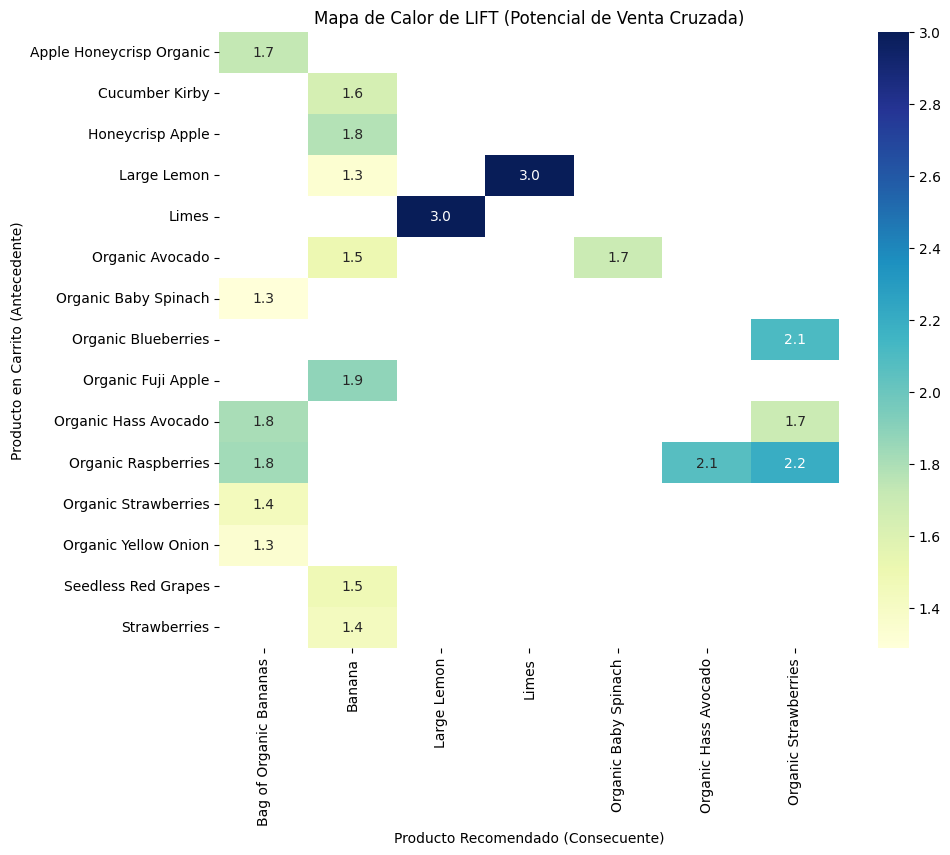

In [8]:
# ==========================================
# 6. VISUALIZACIÓN DEL MAPA DE CALOR
# ==========================================
# Visualizamos la relación Lift entre los productos más conectados
# Filtramos las top reglas para no saturar el gráfico
top_rules = rules.head(20)

# Preparamos datos para el heatmap
# Convertimos frozensets a strings para graficar
top_rules['antecedents_str'] = top_rules['antecedents'].apply(lambda x: list(x)[0])
top_rules['consequents_str'] = top_rules['consequents'].apply(lambda x: list(x)[0])

pivot_rules = top_rules.pivot(index='antecedents_str', 
                            columns='consequents_str', 
                            values='lift')

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_rules, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title('Mapa de Calor de LIFT (Potencial de Venta Cruzada)')
plt.xlabel('Producto Recomendado (Consecuente)')
plt.ylabel('Producto en Carrito (Antecedente)')
plt.show()